# Notebook 4 — LSTM Training (New Dataset)
**Sensor:** TI IWR6843ISK (77 GHz)  
**Dataset:** `Data/Research Data-New/Single Activity/3D data/`  
**Target:** Classify Sitting · Standing · Waiving · Walking  
**Train distances:** 1 m · 2 m · 3 m  
**Test distances:** 4 m · 5 m  

### Key differences from Notebook 3
- Single combined CSV per recording: `PointCloud_snr.csv` (point cloud + SNR merged)
- Distance folders use full names with spaces: `1 m`, `2 m`, …, `5 m`
- Dataset extends to 5 m (one extra test distance)
- New `aoa` column (angle of arrival) added as extra feature
- Same architecture: LSTM(64) → Dense(32) → Dense(4)
- Same excluded features: `mean_y`, `mean_range` (distance-correlated)

### Pipeline
1. Setup & constants  
2. Data loading & per-frame feature extraction  
3. Sliding-window sequence construction  
4. Train / test split & normalisation  
5. LSTM model definition  
6. Training with callbacks  
7. Evaluation — overall & per-distance  
8. Confusion matrix & classification report  
9. Learning-curve plots  
10. Model save  

In [6]:
# ── 1. Setup ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, balanced_accuracy_score, f1_score
)

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, LayerNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_ROOT = Path('Data/Research Data-New/Single Activity/3D data')

ACTIVITIES  = ['Sitting', 'Standing', 'Waiving', 'Walking']
TRAIN_DISTS = ['1 m', '2 m', '3 m']
TEST_DISTS  = ['4 m', '5 m']
ALL_DISTS   = TRAIN_DISTS + TEST_DISTS

# ── Sequence hyperparameters ───────────────────────────────────────────────────
WINDOW_SIZE = 25
STRIDE      = 5
NUM_CLASSES = len(ACTIVITIES)

print(f'TF version : {tf.__version__}')
print(f'Activities : {ACTIVITIES}')
print(f'Train dists: {TRAIN_DISTS}')
print(f'Test  dists: {TEST_DISTS}')
print(f'Window size: {WINDOW_SIZE} frames  |  Stride: {STRIDE}')

TF version : 2.21.0
Data root  : ..\Single Activity\3D data
Activities : ['Sitting', 'Standing', 'Waving', 'Walking']
Train dists: ['1 m', '2 m', '3 m']
Test  dists: ['4 m', '5 m']
Window size: 25 frames  |  Stride: 5


## 2. Data Loading & Per-Frame Feature Extraction

**16 features per frame** extracted from `PointCloud_snr.csv` (single combined file):  
(`mean_y` and `mean_range` excluded — both directly encode sensor-to-target distance,  
causing systematic distribution shift between train (1–3 m) and test (4–5 m).)

| # | Feature | Description |
|---|---------|-------------|
| 1 | `point_count` | Number of detected points |
| 2 | `mean_x` | Mean lateral position |
| 3 | `std_x` | Lateral spread |
| 4 | `std_y` | Depth spread |
| 5 | `mean_z` | Mean height |
| 6 | `std_z` | Height spread |
| 7 | `mean_doppler` | Mean radial velocity |
| 8 | `std_doppler` | Velocity spread |
| 9 | `min_doppler` | Min Doppler (approaching motion) |
| 10 | `max_doppler` | Max Doppler (receding motion) |
| 11 | `abs_doppler` | Mean absolute velocity |
| 12 | `std_range` | Range spread |
| 13 | `mean_aoa` | Mean angle of arrival |
| 14 | `std_aoa` | AoA spread |
| 15 | `mean_snr` | Mean SNR |
| 16 | `mean_noise` | Mean noise floor |

In [7]:
FEATURE_COLS = [
    'point_count', 'mean_x', 'std_x', 'std_y', 'mean_z', 'std_z',
    'mean_doppler', 'std_doppler', 'min_doppler', 'max_doppler', 'abs_doppler',
    'std_range', 'mean_aoa', 'std_aoa', 'mean_snr', 'mean_noise'
]
# mean_y and mean_range excluded: encode absolute sensor distance -> cause
# train/test distribution shift between 1-3 m (train) and 4-5 m (test).
N_FEATURES = len(FEATURE_COLS)
print(f'Features ({N_FEATURES}): {FEATURE_COLS}')

COLUMN_MAP = {
    'azimuth': 'aoa',
    'azimuth_deg': 'aoa',
}

def extract_frame_features(act, dist):
    """
    Load PointCloud_snr.csv for one recording and return
    a DataFrame with one row per frame (sorted by frame_number).
    PointCloud_snr.csv is a combined file: point cloud + SNR + noise in one.
    """
    csv_path = DATA_ROOT / act / dist / 'PointCloud_snr.csv'
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    df = df.rename(columns=COLUMN_MAP)

    required_cols = [
        'frame_number',
        'x', 'y', 'z',
        'doppler', 'range', 'aoa',
        'snr', 'noise'
    ]
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f'Missing columns in {csv_path}: {missing_cols}')

    def agg(g):
        return pd.Series({
            'point_count':  len(g),
            'mean_x':       g['x'].mean(),
            'std_x':        g['x'].std(ddof=0),
            'std_y':        g['y'].std(ddof=0),
            'mean_z':       g['z'].mean(),
            'std_z':        g['z'].std(ddof=0),
            'mean_doppler': g['doppler'].mean(),
            'std_doppler':  g['doppler'].std(ddof=0),
            'min_doppler':  g['doppler'].min(),
            'max_doppler':  g['doppler'].max(),
            'abs_doppler':  g['doppler'].abs().mean(),
            'std_range':    g['range'].std(ddof=0),
            'mean_aoa':     g['aoa'].mean(),
            'std_aoa':      g['aoa'].std(ddof=0),
            'mean_snr':     g['snr'].mean(),
            'mean_noise':   g['noise'].mean(),
        })

    feat = (
        df.groupby('frame_number', sort=True)
          .apply(agg)
          .reset_index()
    )
    feat = feat.fillna(0)
    feat['activity'] = act
    feat['distance'] = dist
    return feat


def build_recording_features(distances):
    frames = []
    for act in ACTIVITIES:
        for dist in distances:
            feat = extract_frame_features(act, dist)
            frames.append(feat)
    return pd.concat(frames, ignore_index=True)


print('Loading training data  (1 m, 2 m, 3 m)...')
train_feat = build_recording_features(TRAIN_DISTS)
print(f'  {len(train_feat)} frames  |  {train_feat["activity"].value_counts().to_dict()}')

print('Loading test data      (4 m, 5 m)...')
test_feat  = build_recording_features(TEST_DISTS)
print(f'  {len(test_feat)} frames  |  {test_feat["activity"].value_counts().to_dict()}')

Features (16): ['point_count', 'mean_x', 'std_x', 'std_y', 'mean_z', 'std_z', 'mean_doppler', 'std_doppler', 'min_doppler', 'max_doppler', 'abs_doppler', 'std_range', 'mean_aoa', 'std_aoa', 'mean_snr', 'mean_noise']
Loading training data  (1 m, 2 m, 3 m)...
  1469 frames  |  {'Standing': 426, 'Sitting': 406, 'Walking': 337, 'Waving': 300}
Loading test data      (4 m, 5 m)...
  1009 frames  |  {'Standing': 297, 'Sitting': 277, 'Walking': 221, 'Waving': 214}


## 3. Sliding-Window Sequence Construction

Each recording is converted into overlapping windows of `WINDOW_SIZE` consecutive frames.  
Windows are built **per-recording** (activity × distance) so boundaries do not cross recordings.

In [8]:
def build_windows(feat_df, window_size=WINDOW_SIZE, stride=STRIDE):
    """
    For each (activity, distance) recording, slide a window over frames
    and collect (sequence, label, distance) tuples.

    Returns:
        X : ndarray  shape (N, window_size, N_FEATURES)
        y : ndarray  shape (N,)  — string activity labels
        d : ndarray  shape (N,)  — distance folder labels
    """
    seqs, labels, dists = [], [], []

    for (act, dist), grp in feat_df.groupby(['activity', 'distance'], sort=False):
        grp    = grp.sort_values('frame_number').reset_index(drop=True)
        values = grp[FEATURE_COLS].values  # (T, N_FEATURES)
        T      = len(values)

        for start in range(0, T - window_size + 1, stride):
            seqs.append(values[start : start + window_size])
            labels.append(act)
            dists.append(dist)

    return (
        np.array(seqs,  dtype=np.float32),
        np.array(labels),
        np.array(dists)
    )


X_train_raw, y_train_str, d_train = build_windows(train_feat)
X_test_raw,  y_test_str,  d_test  = build_windows(test_feat)

print(f'Train windows: {X_train_raw.shape}   labels: {pd.Series(y_train_str).value_counts().to_dict()}')
print(f'Test  windows: {X_test_raw.shape}   labels: {pd.Series(y_test_str).value_counts().to_dict()}')

Train windows: (241, 25, 16)   labels: {'Standing': 72, 'Sitting': 68, 'Walking': 55, 'Waving': 46}
Test  windows: (167, 25, 16)   labels: {'Standing': 51, 'Sitting': 47, 'Walking': 35, 'Waving': 34}


## 4. Feature Normalisation & Label Encoding

X_train: (241, 25, 16)  y_train: (241, 4)
X_test : (167, 25, 16)   y_test : (167, 4)
Classes: [np.str_('Sitting'), np.str_('Standing'), np.str_('Walking'), np.str_('Waving')]


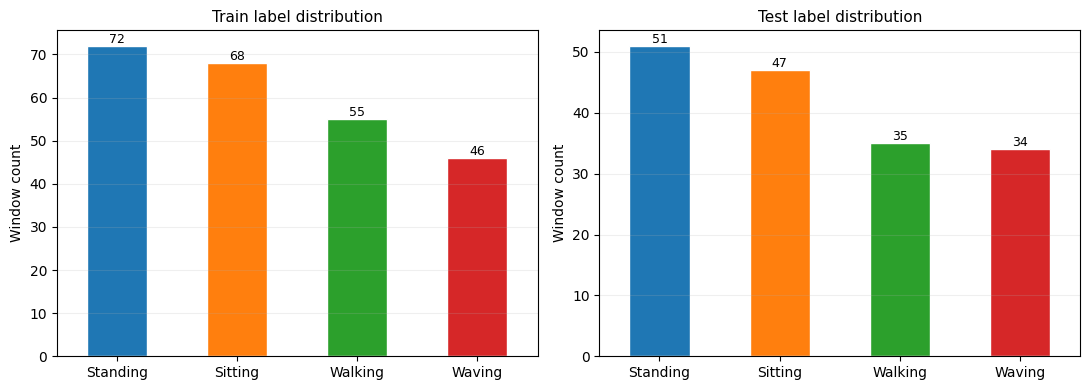

In [9]:
# ── Normalise feature-wise (fit ONLY on train data) ────────────────────────────
N_train, T, F = X_train_raw.shape
N_test        = X_test_raw.shape[0]

scaler    = StandardScaler()
X_train_2d = X_train_raw.reshape(-1, F)
X_test_2d  = X_test_raw.reshape(-1, F)

scaler.fit(X_train_2d)
X_train = scaler.transform(X_train_2d).reshape(N_train, T, F).astype(np.float32)
X_test  = scaler.transform(X_test_2d ).reshape(N_test,  T, F).astype(np.float32)

# ── Label encoding ─────────────────────────────────────────────────────────────
le = LabelEncoder()
le.fit(ACTIVITIES)

y_train_idx = le.transform(y_train_str)
y_test_idx  = le.transform(y_test_str)
y_train_oh  = to_categorical(y_train_idx, num_classes=NUM_CLASSES)
y_test_oh   = to_categorical(y_test_idx,  num_classes=NUM_CLASSES)

print(f'X_train: {X_train.shape}  y_train: {y_train_oh.shape}')
print(f'X_test : {X_test.shape}   y_test : {y_test_oh.shape}')
print(f'Classes: {list(le.classes_)}')

# Label distribution
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, counts, title in zip(
    axes,
    [pd.Series(y_train_str).value_counts(), pd.Series(y_test_str).value_counts()],
    ['Train label distribution', 'Test label distribution']
):
    counts.plot.bar(ax=ax, color=sns.color_palette('tab10', NUM_CLASSES), edgecolor='white')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Window count')
    ax.tick_params(axis='x', rotation=0)
    ax.grid(True, alpha=0.2, axis='y')
    for p in ax.patches:
        ax.annotate(str(int(p.get_height())),
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('new_lstm_label_dist.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. LSTM Model Definition

Same architecture as Notebook 3 — kept small to match the dataset size.

```
Input (20 frames × 16 features)
  └─ LSTM(64) → LayerNorm → Dropout(0.3)
       └─ Dense(32, relu) → Dropout(0.25)
            └─ Dense(4, softmax)
```

In [10]:
def build_lstm_model(window_size=WINDOW_SIZE, n_features=N_FEATURES,
                     num_classes=NUM_CLASSES):
    inp = Input(shape=(window_size, n_features), name='frame_sequence')

    x   = LSTM(64, return_sequences=False, name='lstm_1')(inp)
    x   = LayerNormalization()(x)
    x   = Dropout(0.30)(x)

    x   = Dense(32, activation='relu')(x)
    x   = Dropout(0.25)(x)
    out = Dense(num_classes, activation='softmax', name='class_output')(x)

    model = Model(inputs=inp, outputs=out, name='LSTM_Classifier_NewData')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


model = build_lstm_model()
model.summary()

Model: "LSTM_Classifier_NewData"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ frame_sequence (InputLayer)     │ (None, 25, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 64)             │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_output (Dense)            │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,076 (90.14 KB)

 Trainable params: 23,076 (90.14 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Training

In [11]:
EPOCHS     = 100
BATCH_SIZE = 16
VAL_SPLIT  = 0.15

os.makedirs('checkpoints', exist_ok=True)

callbacks = [
    EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=7,
        min_lr=1e-6, verbose=1
    ),
    ModelCheckpoint(
        'checkpoints/best_model_new_data.keras',
        monitor='val_accuracy', save_best_only=True,
        mode='max', verbose=0
    ),
]

history = model.fit(
    X_train, y_train_oh,
    validation_split=VAL_SPLIT,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

print(f'\nTraining stopped at epoch {len(history.history["loss"])}')

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.4363 - loss: 1.3849 - val_accuracy: 0.1081 - val_loss: 1.8652 - learning_rate: 0.0010
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.6176 - loss: 0.8811 - val_accuracy: 0.3784 - val_loss: 1.2415 - learning_rate: 0.0010
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6373 - loss: 0.7742 - val_accuracy: 0.6486 - val_loss: 0.7927 - learning_rate: 0.0010
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7059 - loss: 0.6391 - val_accuracy: 0.8649 - val_loss: 0.4429 - learning_rate: 0.0010
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7157 - loss: 0.5866 - val_accuracy: 0.8919 - val_loss: 0.3152 - learning_rate: 0.0010
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7990 - loss: 0.4864 - val_accuracy: 0.8919 - val_loss: 0.3150 - learning_rate: 0.0010
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7745 - loss: 0.5032 - 

## 7. Overall Evaluation on Test Set (4 m + 5 m)

In [12]:
test_loss, test_acc = model.evaluate(X_test, y_test_oh, verbose=0)
print(f'Test loss    : {test_loss:.4f}')
print(f'Test accuracy: {test_acc:.4f}')

y_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
y_true = y_test_idx

bal_acc  = balanced_accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average='macro')
print(f'Balanced accuracy: {bal_acc:.4f}')
print(f'Macro F1-score   : {macro_f1:.4f}')

print('\nClassification report:')
print(classification_report(y_true, y_pred,
                             target_names=le.classes_, zero_division=0))

Test loss    : 1.3059
Test accuracy: 0.5629
Balanced accuracy: 0.5821
Macro F1-score   : 0.5625

Classification report:
              precision    recall  f1-score   support

     Sitting       0.41      0.89      0.56        47
    Standing       0.47      0.14      0.21        51
     Walking       1.00      0.89      0.94        35
      Waving       0.78      0.41      0.54        34

    accuracy                           0.56       167
   macro avg       0.66      0.58      0.56       167
weighted avg       0.63      0.56      0.53       167



## 8. Confusion Matrix

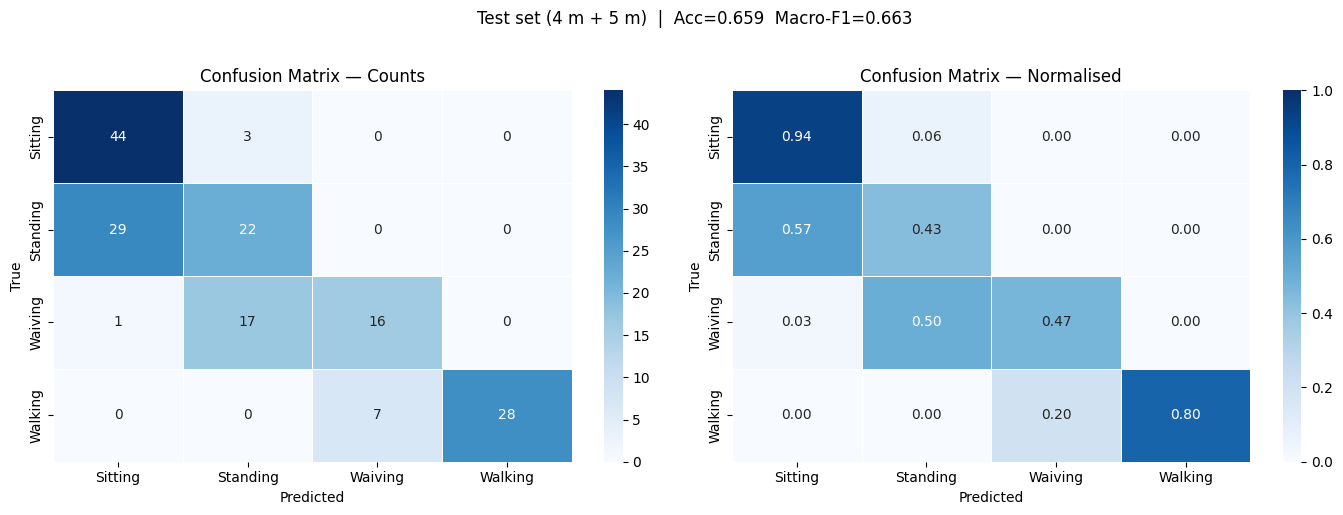

In [50]:
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=axes[0], linewidths=0.4)
axes[0].set_title('Confusion Matrix — Counts', fontsize=12)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            vmin=0, vmax=1, ax=axes[1], linewidths=0.4)
axes[1].set_title('Confusion Matrix — Normalised', fontsize=12)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.suptitle(f'Test set (4 m + 5 m)  |  Acc={test_acc:.3f}  Macro-F1={macro_f1:.3f}',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('new_lstm_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

## Per-Distance Performance Breakdown

In [51]:
print('=' * 55)
print('Per-Distance Performance on Test Set')
print('=' * 55)

dist_metrics = []
for dist in TEST_DISTS:
    mask  = d_test == dist
    if mask.sum() == 0:
        continue
    yt_d  = y_true[mask]
    yp_d  = y_pred[mask]
    acc_d = accuracy_score(yt_d, yp_d)
    f1_d  = f1_score(yt_d, yp_d, average='macro', zero_division=0)
    bal_d = balanced_accuracy_score(yt_d, yp_d)
    dist_metrics.append({'Distance': dist, 'Samples': int(mask.sum()),
                          'Accuracy': round(acc_d, 4),
                          'Balanced Acc': round(bal_d, 4),
                          'Macro F1': round(f1_d, 4)})
    print(f'\n  Distance: {dist}  ({mask.sum()} windows)')
    print(f'  Accuracy={acc_d:.4f}  BalAcc={bal_d:.4f}  MacroF1={f1_d:.4f}')
    print(classification_report(yt_d, yp_d, target_names=le.classes_,
                                  zero_division=0, digits=3))

dist_df = pd.DataFrame(dist_metrics)
print(dist_df.to_string(index=False))

Per-Distance Performance on Test Set

  Distance: 4 m  (78 windows)
  Accuracy=0.9487  BalAcc=0.9565  MacroF1=0.9564
              precision    recall  f1-score   support

     Sitting      0.952     0.870     0.909        23
    Standing      0.880     0.957     0.917        23
     Waiving      1.000     1.000     1.000        16
     Walking      1.000     1.000     1.000        16

    accuracy                          0.949        78
   macro avg      0.958     0.957     0.956        78
weighted avg      0.951     0.949     0.949        78


  Distance: 5 m  (89 windows)
  Accuracy=0.4045  BalAcc=0.4079  MacroF1=0.3494
              precision    recall  f1-score   support

     Sitting      0.453     1.000     0.623        24
    Standing      0.000     0.000     0.000        28
     Waiving      0.000     0.000     0.000        18
     Walking      1.000     0.632     0.774        19

    accuracy                          0.404        89
   macro avg      0.363     0.408     0.34

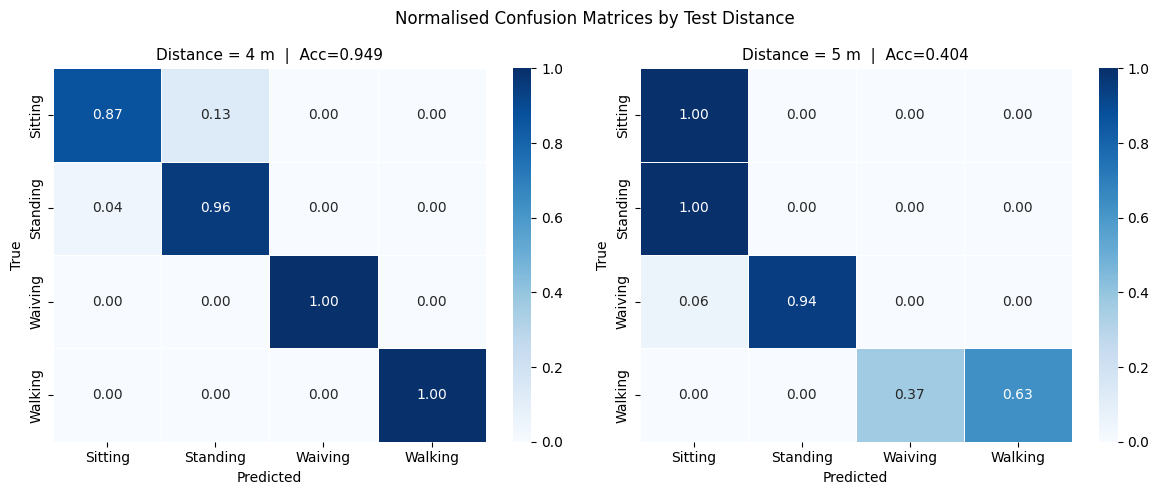

In [52]:
# Per-distance confusion matrices
fig, axes = plt.subplots(1, len(TEST_DISTS), figsize=(6 * len(TEST_DISTS), 5))
if len(TEST_DISTS) == 1:
    axes = [axes]

for ax, dist in zip(axes, TEST_DISTS):
    mask = d_test == dist
    if mask.sum() == 0:
        ax.set_visible(False)
        continue
    cm_d      = confusion_matrix(y_true[mask], y_pred[mask])
    cm_d_norm = cm_d.astype(float) / cm_d.sum(axis=1, keepdims=True)
    sns.heatmap(cm_d_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_,
                vmin=0, vmax=1, ax=ax, linewidths=0.4)
    acc_d = accuracy_score(y_true[mask], y_pred[mask])
    ax.set_title(f'Distance = {dist}  |  Acc={acc_d:.3f}', fontsize=11)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.suptitle('Normalised Confusion Matrices by Test Distance', fontsize=12)
plt.tight_layout()
plt.savefig('new_lstm_cm_per_distance.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Learning Curves

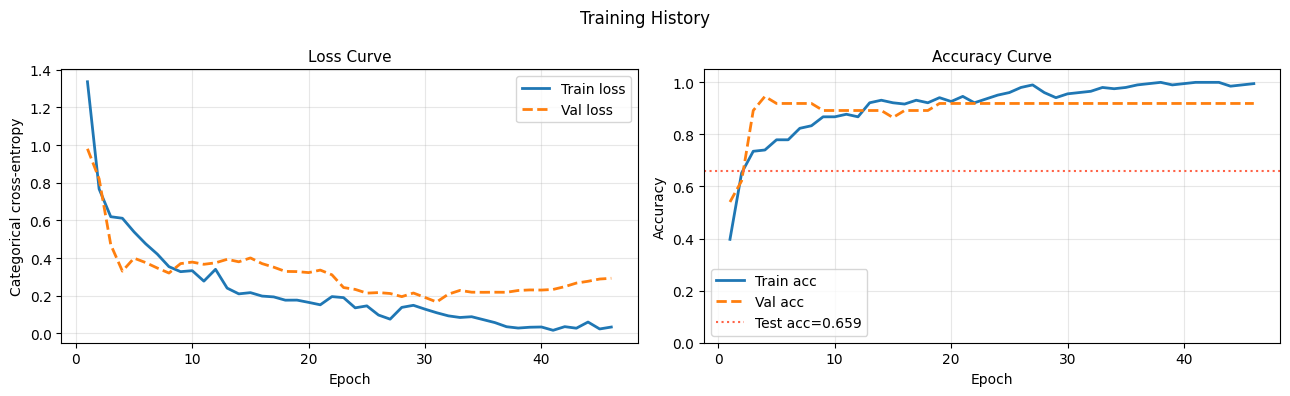

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
epochs_ran = range(1, len(history.history['loss']) + 1)

axes[0].plot(epochs_ran, history.history['loss'],     label='Train loss',  linewidth=2)
axes[0].plot(epochs_ran, history.history['val_loss'], label='Val loss',    linewidth=2, linestyle='--')
axes[0].set_title('Loss Curve', fontsize=11)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Categorical cross-entropy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, history.history['accuracy'],     label='Train acc',  linewidth=2)
axes[1].plot(epochs_ran, history.history['val_accuracy'], label='Val acc',    linewidth=2, linestyle='--')
axes[1].axhline(test_acc, color='tomato', linewidth=1.5, linestyle=':',
                label=f'Test acc={test_acc:.3f}')
axes[1].set_title('Accuracy Curve', fontsize=11)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05)
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Training History', fontsize=12)
plt.tight_layout()
plt.savefig('new_lstm_learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()

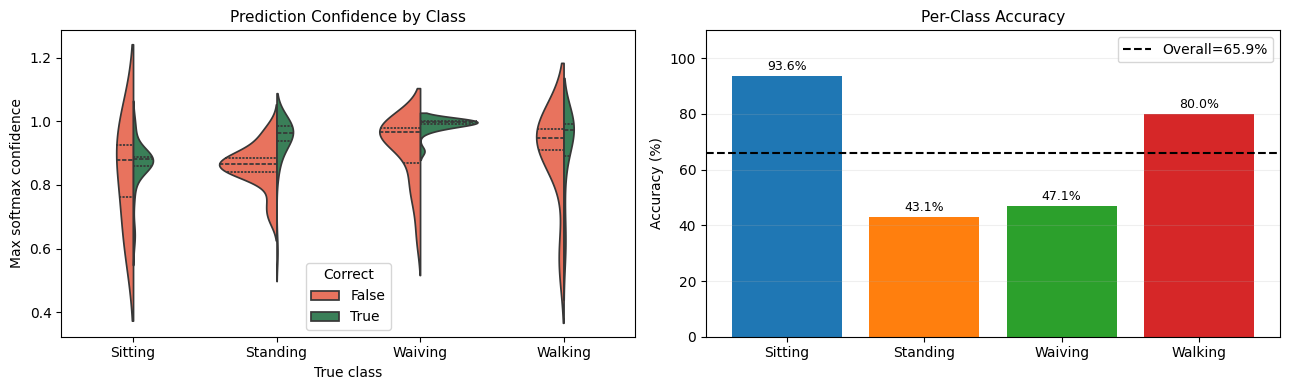

In [54]:
# Per-class confidence distribution
conf_df = pd.DataFrame({
    'true_label': [le.classes_[i] for i in y_true],
    'pred_label': [le.classes_[i] for i in y_pred],
    'confidence': y_prob.max(axis=1),
    'correct':    y_true == y_pred,
})

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.violinplot(data=conf_df, x='true_label', y='confidence',
               hue='correct', split=True, inner='quartile',
               palette={True: 'seagreen', False: 'tomato'}, ax=axes[0])
axes[0].set_title('Prediction Confidence by Class', fontsize=11)
axes[0].set_xlabel('True class'); axes[0].set_ylabel('Max softmax confidence')
axes[0].legend(title='Correct')

class_acc = conf_df.groupby('true_label')['correct'].mean().reindex(ACTIVITIES)
axes[1].bar(class_acc.index, class_acc.values * 100,
            color=sns.color_palette('tab10', NUM_CLASSES))
axes[1].axhline(test_acc * 100, color='black', linewidth=1.5,
                linestyle='--', label=f'Overall={test_acc*100:.1f}%')
axes[1].set_title('Per-Class Accuracy', fontsize=11)
axes[1].set_xlabel(''); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(0, 110)
axes[1].legend(); axes[1].grid(True, alpha=0.2, axis='y')
for i, v in enumerate(class_acc.values):
    axes[1].text(i, v * 100 + 2, f'{v*100:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('new_lstm_class_confidence.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Save Model & Scaler

In [55]:
import joblib

model.save('new_data_lstm_classifier.keras')
print('Model saved → new_data_lstm_classifier.keras')

joblib.dump(scaler, 'new_data_feature_scaler.pkl')
print('Scaler saved → new_data_feature_scaler.pkl')

joblib.dump(le, 'new_data_label_encoder.pkl')
print('Label encoder saved → new_data_label_encoder.pkl')

print('\n' + '=' * 55)
print('TRAINING SUMMARY')
print('=' * 55)
print(f'  Dataset        : Research Data-New / Single Activity')
print(f'  Model          : LSTM(64) + Dense(32)')
print(f'  Input shape    : ({WINDOW_SIZE}, {N_FEATURES})')
print(f'  Parameters     : {model.count_params():,}')
print(f'  Train windows  : {len(X_train)}')
print(f'  Test  windows  : {len(X_test)}')
print(f'  Test accuracy  : {test_acc:.4f}')
print(f'  Macro F1       : {macro_f1:.4f}')
print(f'  Balanced acc   : {bal_acc:.4f}')
print('=' * 55)

Model saved → new_data_lstm_classifier.keras
Scaler saved → new_data_feature_scaler.pkl
Label encoder saved → new_data_label_encoder.pkl

TRAINING SUMMARY
  Dataset        : Research Data-New / Single Activity
  Model          : LSTM(64) + Dense(32)
  Input shape    : (25, 16)
  Parameters     : 23,076
  Train windows  : 241
  Test  windows  : 167
  Test accuracy  : 0.6587
  Macro F1       : 0.6627
  Balanced acc   : 0.6595


## Appendix — Quick Inference on a New Recording

In [56]:
def predict_activity(act, dist, model=model, scaler=scaler, le=le,
                     window_size=WINDOW_SIZE):
    """
    Predict activity class for a single recording.
    Returns predicted label and mean confidence.
    """
    feat   = extract_frame_features(act, dist)
    values = feat[FEATURE_COLS].values

    seqs = []
    for start in range(0, len(values) - window_size + 1, STRIDE):
        seqs.append(values[start : start + window_size])

    if len(seqs) == 0:
        print(f'  Recording too short ({len(values)} frames < window {window_size})')
        return None, None

    X_new = np.array(seqs, dtype=np.float32)
    X_new = scaler.transform(X_new.reshape(-1, N_FEATURES)).reshape(
        len(seqs), window_size, N_FEATURES
    )

    probs = model.predict(X_new, verbose=0)
    votes = np.argmax(probs, axis=1)
    final = np.bincount(votes, minlength=NUM_CLASSES).argmax()

    return le.classes_[final], probs.max(axis=1).mean()


print('Inference demo (test distances):')
for act in ACTIVITIES:
    for dist in TEST_DISTS:
        pred, conf = predict_activity(act, dist)
        correct = '✓' if pred == act else '✗'
        print(f'  {correct}  True={act:12}  Pred={str(pred):12}  Conf={conf:.3f}  Dist={dist}')

Inference demo (test distances):
  ✓  True=Sitting       Pred=Sitting       Conf=0.826  Dist=4 m
  ✓  True=Sitting       Pred=Sitting       Conf=0.895  Dist=5 m
  ✓  True=Standing      Pred=Standing      Conf=0.935  Dist=4 m
  ✗  True=Standing      Pred=Sitting       Conf=0.859  Dist=5 m
  ✓  True=Waiving       Pred=Waiving       Conf=0.989  Dist=4 m
  ✗  True=Waiving       Pred=Standing      Conf=0.911  Dist=5 m
  ✓  True=Walking       Pred=Walking       Conf=0.965  Dist=4 m
  ✓  True=Walking       Pred=Walking       Conf=0.856  Dist=5 m
